In [1]:
import scanpy as sc
import pandas as pd
from anndata import AnnData

adata_final = sc.read_h5ad("data/scgeo_gse280305_final_integrated.h5ad")

adata_final

AnnData object with n_obs × n_vars = 31605 × 1500
    obs: 'timepoint', 'sample', 'gsm', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'macrostates_fwd', 'term_states_fwd', 'term_states_fwd_probs', 'leiden_raw', 'alignment_group', 'cluster_label_mannual', 'scgeo_pred', 'scgeo_conf_entropy', 'scgeo_conf_margin', 'scgeo_conf', 'scgeo_ood', 'scgeo_reject', 'hematlas_pred', 'hematlas_conf_entropy', 'hematlas_conf_margin', 'hematlas_conf', 'hematlas_ood', 'hematlas_flag', 'cluster_label_manual', 'reference_status', 'state_alignment', 'state_reference'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'alignment_group_colors', 'coarse_fwd', 'eigendecomposition_fwd', 'leiden_raw_colors', 'lineages_gpcca_names', 'macrostates_fwd_colors', 'neighbors', 'pca', 'sch

In [2]:
import scgeo as sg

In [3]:
deg_global = sg.tl.alignment_driver_genes(
    adata_final,
    alignment_key="alignment_group",
    group1="discordant",
    group2="aligned",
    layer="matrix",
    min_cells=50,
    key_added="alignment_driver_genes_global",
)

deg_global.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,subset,group1,group2
0,Cd34,47.638973,6.032700,0.000000e+00,0.000000e+00,0.548216,all,discordant,aligned
1,Adgrl4,34.950218,3.441214,1.285152e-267,9.638643e-266,0.500586,all,discordant,aligned
2,Emb,34.432323,9.978070,8.282176e-260,5.176360e-258,0.565628,all,discordant,aligned
3,Ccl9,31.912859,4.271279,1.770757e-223,8.300423e-222,0.488483,all,discordant,aligned
4,Plppr3,31.056442,2.593274,9.337983e-212,3.785669e-210,0.459202,all,discordant,aligned
5,Satb1,29.613916,2.524580,9.891955e-193,3.532841e-191,0.312173,all,discordant,aligned
6,Ccl3,29.382513,5.217405,9.186806e-190,3.131866e-188,0.372062,all,discordant,aligned
7,Tmem176b,23.414433,2.950211,3.046567e-121,4.394087e-120,0.560006,all,discordant,aligned
8,S100a4,22.475523,1.308791,7.205083e-112,9.082037e-111,0.280862,all,discordant,aligned
9,Flt3,22.427601,1.592497,2.117492e-111,2.624990e-110,0.384399,all,discordant,aligned


In [4]:
adata_final.obs["state_set"] = "other"

discordant_set = [
    "stress-associated / ambiguous",
    "stressed erythroid-like",
    "stressed myeloid-like",
    "macrophage-like / remodeling myeloid",
    "divergent erythroid-like",
    "activated APC-like",
    "transitional erythroid",
]

canonical_set = [
    "HSC / primitive progenitor-like",
    "granulocytic / emergency myeloid",
    "B-lineage / pre-B-like",
    "T/NK-like lymphoid",
]

erythroid_discordant = [
    "stress-associated / ambiguous",
    "stressed erythroid-like",
    "divergent erythroid-like",
    "transitional erythroid",
]

erythroid_canonical = [
    "erythroid progenitor-like",
    "stable erythroid",
]

myeloid_discordant = [
    "stressed myeloid-like",
    "macrophage-like / remodeling myeloid",
    "activated APC-like",
]

myeloid_canonical = [
    "granulocytic / emergency myeloid",
    "stable APC-like",
]

adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(discordant_set),
    "state_set"
] = "discordant_set"

adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(canonical_set),
    "state_set"
] = "canonical_set"

adata_final.obs["ery_state_set"] = "other"
adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(erythroid_discordant),
    "ery_state_set"
] = "ery_discordant"
adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(erythroid_canonical),
    "ery_state_set"
] = "ery_canonical"

adata_final.obs["my_state_set"] = "other"
adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(myeloid_discordant),
    "my_state_set"
] = "my_discordant"
adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(myeloid_canonical),
    "my_state_set"
] = "my_canonical"

In [5]:
adata_final.obs["state_set"] = "other"

discordant_set = [
    "stress-associated / ambiguous",
    "stressed erythroid-like",
    "stressed myeloid-like",
    "macrophage-like / remodeling myeloid",
    "divergent erythroid-like",
    "activated APC-like",
    "transitional erythroid",
]

canonical_set = [
    "HSC / primitive progenitor-like",
    "granulocytic / emergency myeloid",
    "B-lineage / pre-B-like",
    "T/NK-like lymphoid",
]

adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(discordant_set),
    "state_set"
] = "discordant_set"

adata_final.obs.loc[
    adata_final.obs["cluster_label_manual"].isin(canonical_set),
    "state_set"
] = "canonical_set"

In [6]:
for key in ["state_set", "ery_state_set", "my_state_set"]:
    print("\n", key)
    print(adata_final.obs[key].value_counts())


 state_set
state_set
other             14944
discordant_set     8755
canonical_set      7906
Name: count, dtype: int64

 ery_state_set
ery_state_set
other             17832
ery_canonical      7161
ery_discordant     6612
Name: count, dtype: int64

 my_state_set
my_state_set
other            24162
my_canonical      5300
my_discordant     2143
Name: count, dtype: int64


In [7]:
deg_global_sets = sg.tl.alignment_driver_genes(
    adata_final,
    alignment_key="state_set",
    group1="discordant_set",
    group2="canonical_set",
    layer="matrix",
    min_cells=50,
    key_added="deg_state_set_global",
)

deg_global_sets.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,subset,group1,group2
0,Car1,47.392914,14.918288,0.000000e+00,0.000000e+00,0.663507,all,discordant_set,canonical_set
1,Slc25a21,43.306118,8.101594,0.000000e+00,0.000000e+00,0.435180,all,discordant_set,canonical_set
2,Ermap,39.694241,5.646506,0.000000e+00,0.000000e+00,0.387550,all,discordant_set,canonical_set
3,Ank1,34.407375,5.386161,1.956047e-259,7.138857e-259,0.332724,all,discordant_set,canonical_set
4,Abcb4,32.344379,4.186830,1.664216e-229,5.901475e-229,0.345517,all,discordant_set,canonical_set
5,Aqp1,32.241451,4.421471,4.635988e-228,1.636231e-227,0.360366,all,discordant_set,canonical_set
6,Nfia,32.025997,4.612529,4.740434e-225,1.669167e-224,0.424329,all,discordant_set,canonical_set
7,Myo1d,31.890434,4.403255,3.623782e-223,1.270017e-222,0.332267,all,discordant_set,canonical_set
8,Klf1,31.640591,4.824313,1.021650e-219,3.555628e-219,0.347344,all,discordant_set,canonical_set
9,Gm15915,31.582874,4.251081,6.345366e-219,2.203252e-218,0.385837,all,discordant_set,canonical_set


In [8]:
deg_ery_sets = sg.tl.alignment_driver_genes(
    adata_final,
    alignment_key="ery_state_set",
    group1="ery_discordant",
    group2="ery_canonical",
    layer="matrix",
    min_cells=30,
    key_added="deg_state_set_ery",
)

deg_ery_sets.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,subset,group1,group2
0,Adgrl4,2.697426,2.173223,0.006988,0.011010,0.054900,all,ery_discordant,ery_canonical
1,Arid5b,1.771933,1.333231,0.076406,0.113925,0.042045,all,ery_discordant,ery_canonical
2,Trf,1.719234,1.691442,0.085572,0.127339,0.036146,all,ery_discordant,ery_canonical
3,Atp8b4,1.672157,2.098537,0.094493,0.139921,0.051875,all,ery_discordant,ery_canonical
4,Mgst1,1.559463,1.820405,0.118887,0.174259,0.036298,all,ery_discordant,ery_canonical
5,Slc4a1,1.551594,4.237912,0.120759,0.176549,0.020115,all,ery_discordant,ery_canonical
6,Gria3,1.495202,1.685553,0.134862,0.196020,0.030248,all,ery_discordant,ery_canonical
7,Cd34,1.429658,2.261712,0.152815,0.221044,0.061706,all,ery_discordant,ery_canonical
8,Nrg2,1.401446,1.848630,0.161081,0.232552,0.031458,all,ery_discordant,ery_canonical
9,Parp8,1.259429,1.567517,0.207875,0.295275,0.061252,all,ery_discordant,ery_canonical


In [9]:
deg_my_sets = sg.tl.alignment_driver_genes(
    adata_final,
    alignment_key="my_state_set",
    group1="my_discordant",
    group2="my_canonical",
    layer="matrix",
    min_cells=30,
    key_added="deg_state_set_my",
)

deg_my_sets.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,subset,group1,group2
0,Gm26917,10.475589,2.721950,1.118390e-25,2.545653e-25,0.747084,all,my_discordant,my_canonical
1,Fabp4,8.515102,12.367594,1.664439e-17,3.443666e-17,0.156790,all,my_discordant,my_canonical
2,Tgfbr3,8.275433,2.510035,1.279901e-16,2.608493e-16,0.190854,all,my_discordant,my_canonical
3,Gimap6,8.162070,2.721096,3.293314e-16,6.666628e-16,0.210919,all,my_discordant,my_canonical
4,Sparc,7.933599,9.422615,2.128842e-15,4.286259e-15,0.121325,all,my_discordant,my_canonical
5,Stab2,7.862815,9.727946,3.755944e-15,7.542056e-15,0.119925,all,my_discordant,my_canonical
6,Esam,7.826974,5.247602,4.997536e-15,1.000842e-14,0.126458,all,my_discordant,my_canonical
7,Magi1,7.406231,5.152783,1.299389e-13,2.571351e-13,0.125525,all,my_discordant,my_canonical
8,Galnt18,7.400334,8.880776,1.358421e-13,2.684626e-13,0.110593,all,my_discordant,my_canonical
9,Abcc9,7.214347,9.322388,5.419335e-13,1.046204e-12,0.107326,all,my_discordant,my_canonical


In [10]:
def filter_deg(df, lfc=0.25, padj=0.05):
    return df.query("pvals_adj < @padj and logfoldchanges > @lfc").copy()

deg_global_sig = filter_deg(deg_global_sets)
deg_ery_sig = filter_deg(deg_ery_sets)
deg_my_sig = filter_deg(deg_my_sets)

print(len(deg_global_sig), len(deg_ery_sig), len(deg_my_sig))

148 18 180


In [11]:
deg_global_sets.to_csv("data/deg_state_set_global.csv", index=False)
deg_global_sig.to_csv("data/deg_state_set_global_sig.csv", index=False)

deg_ery_sets.to_csv("data/deg_state_set_ery.csv", index=False)
deg_ery_sig.to_csv("data/deg_state_set_ery_sig.csv", index=False)

deg_my_sets.to_csv("data/deg_state_set_my.csv", index=False)
deg_my_sig.to_csv("data/deg_state_set_my_sig.csv", index=False)

In [12]:
import gseapy as gp

def run_hallmark_enrichr(df_sig, name):
    genes = df_sig["names"].dropna().tolist()
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=["MSigDB_Hallmark_2020"],
        organism="mouse",
        outdir=None,
    )
    res = enr.results.copy()
    res["contrast"] = name
    return res

enr_global = run_hallmark_enrichr(deg_global_sig, "global_discordant_vs_canonical")
enr_ery = run_hallmark_enrichr(deg_ery_sig, "ery_discordant_vs_canonical")
enr_my = run_hallmark_enrichr(deg_my_sig, "my_discordant_vs_canonical")

In [13]:
enr_all = pd.concat([enr_global, enr_ery, enr_my], ignore_index=True)
enr_all.to_csv("data/enrichment_hallmark_state_sets.csv", index=False)
enr_all.head(20)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,contrast
0,MSigDB_Hallmark_2020,heme Metabolism,15/200,2.417270e-11,8.218719e-10,0,0,11.989636,293.096216,GYPA;ALAS2;ARHGEF12;CPOX;ANK1;SPTB;ADD2;RHD;KL...,global_discordant_vs_canonical
1,MSigDB_Hallmark_2020,Interferon Gamma Response,6/200,3.779224e-03,6.424681e-02,0,0,4.281545,23.883471,CD74;CIITA;CXCL9;VCAM1;IRF7;ISG15,global_discordant_vs_canonical
2,MSigDB_Hallmark_2020,Interferon Alpha Response,4/97,5.859919e-03,6.641242e-02,0,0,5.901732,30.332658,CD74;IRF7;ISG15;GBP2,global_discordant_vs_canonical
3,MSigDB_Hallmark_2020,Adipogenesis,5/200,1.666153e-02,1.083129e-01,0,0,3.524655,14.432238,FABP4;CYP4B1;PPARG;CD36;SORBS1,global_discordant_vs_canonical
4,MSigDB_Hallmark_2020,Myogenesis,5/200,1.666153e-02,1.083129e-01,0,0,3.524655,14.432238,SPARC;IGFBP7;CD36;SORBS1;LPIN1,global_discordant_vs_canonical
5,MSigDB_Hallmark_2020,Coagulation,4/138,1.941595e-02,1.083129e-01,0,0,4.087479,16.111454,F8;SPARC;HPN;CRIP2,global_discordant_vs_canonical
6,MSigDB_Hallmark_2020,UV Response Dn,4/144,2.229972e-02,1.083129e-01,0,0,3.911111,14.874665,TGFBR3;TJP1;NFIB;PPARG,global_discordant_vs_canonical
7,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,4/199,6.062482e-02,1.609038e-01,0,0,2.800142,7.848942,ADAM19;RABGAP1L;AHR;PLPP1,global_discordant_vs_canonical
8,MSigDB_Hallmark_2020,Apical Junction,4/200,6.152203e-02,1.609038e-01,0,0,2.785714,7.767574,TJP1;ADAMTS5;VCAM1;MYH10,global_discordant_vs_canonical
9,MSigDB_Hallmark_2020,Complement,4/200,6.152203e-02,1.609038e-01,0,0,2.785714,7.767574,F8;IRF7;CD36;ZFPM2,global_discordant_vs_canonical


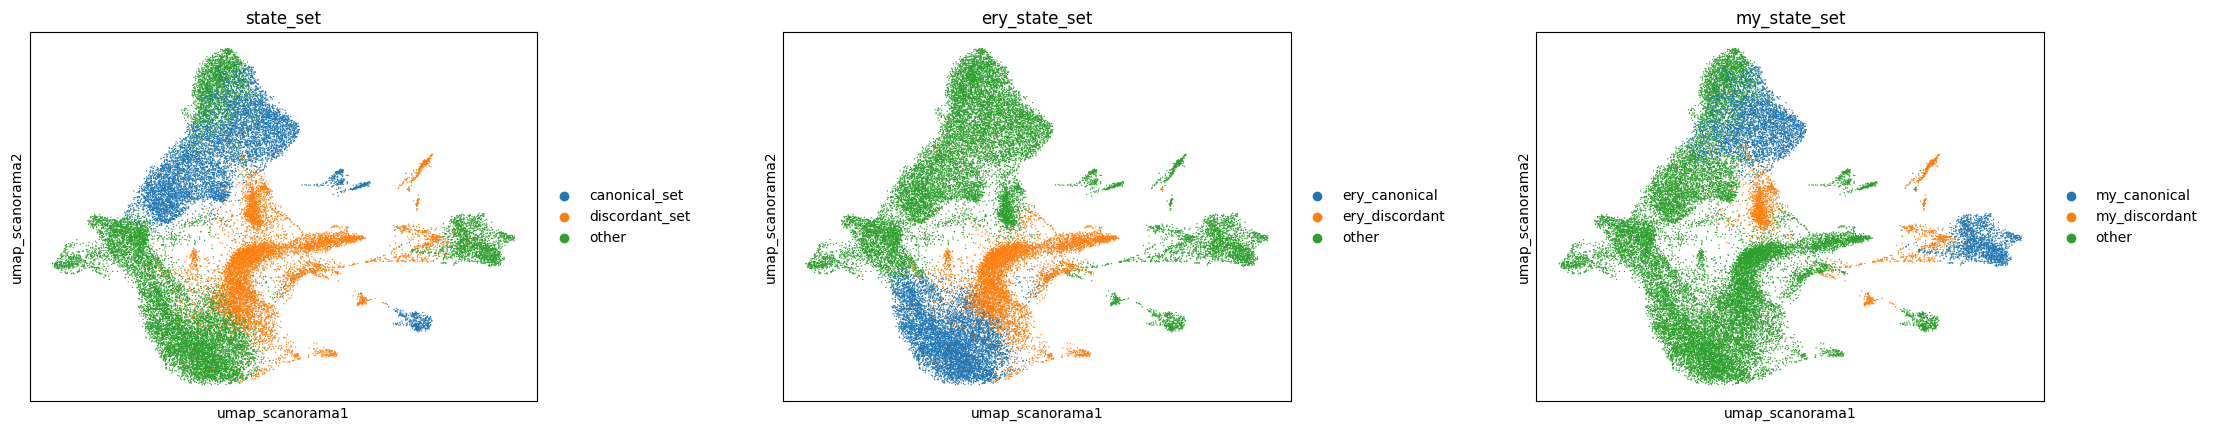

In [14]:
sc.pl.embedding(
    adata_final,
    basis="umap_scanorama",
    color=["state_set", "ery_state_set", "my_state_set"],
    wspace=0.35,
)

In [15]:
top_global = deg_global_sig["names"].head(12).tolist()
top_ery = deg_ery_sig["names"].head(12).tolist()
top_my = deg_my_sig["names"].head(12).tolist()

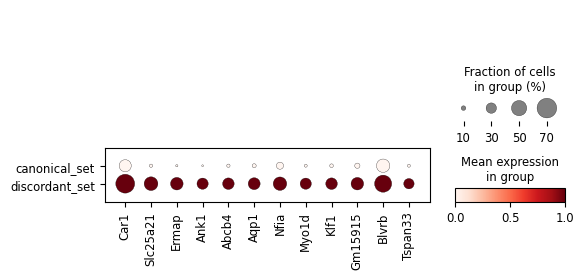

In [16]:
mask = adata_final.obs["state_set"].isin(["discordant_set", "canonical_set"])
sc.pl.dotplot(
    adata_final[mask],
    var_names=top_global,
    groupby="state_set",
    layer="matrix",
    standard_scale="var",
)

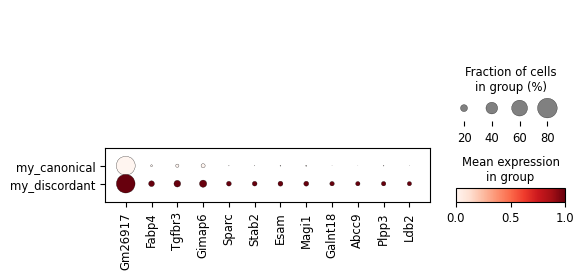

In [17]:
mask = adata_final.obs["my_state_set"].isin(["my_discordant", "my_canonical"])
sc.pl.dotplot(
    adata_final[mask],
    var_names=top_my,
    groupby="my_state_set",
    layer="matrix",
    standard_scale="var",
)

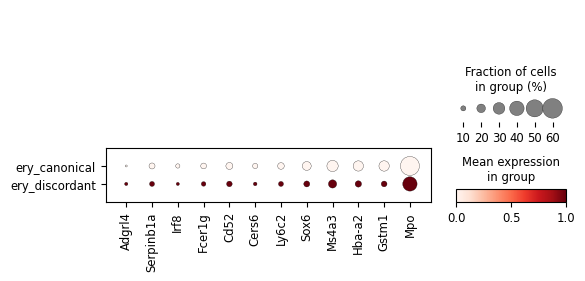

In [18]:
mask = adata_final.obs["ery_state_set"].isin(["ery_discordant", "ery_canonical"])
sc.pl.dotplot(
    adata_final[mask],
    var_names=top_ery,
    groupby="ery_state_set",
    layer="matrix",
    standard_scale="var",
)

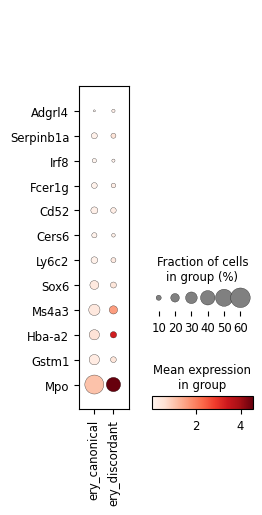

In [19]:
sc.pl.dotplot(
    adata_final[mask],
    var_names=top_ery,
    groupby="ery_state_set",
    layer="matrix",
    swap_axes=True,
)

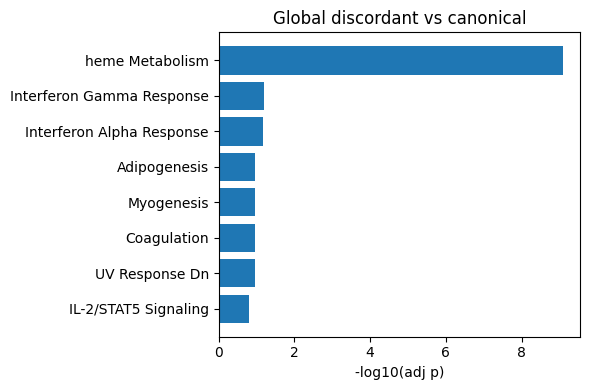

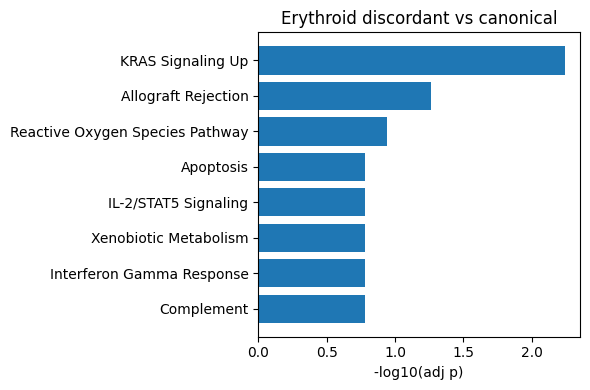

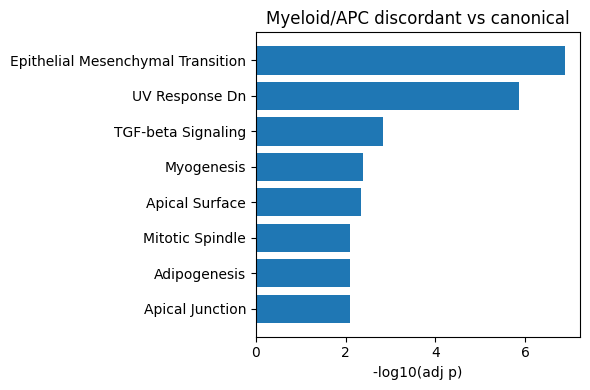

In [20]:
import matplotlib.pyplot as plt
import numpy as np
def plot_enrichment_bar(res, title, top_n=8):
    df = res.sort_values("Adjusted P-value").head(top_n).copy()
    df = df.iloc[::-1]
    score = -np.log10(df["Adjusted P-value"])
    plt.figure(figsize=(6, 4))
    plt.barh(df["Term"], score)
    plt.xlabel("-log10(adj p)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_enrichment_bar(enr_global, "Global discordant vs canonical")
plot_enrichment_bar(enr_ery, "Erythroid discordant vs canonical")
plot_enrichment_bar(enr_my, "Myeloid/APC discordant vs canonical")

In [21]:
import scvelo as scv

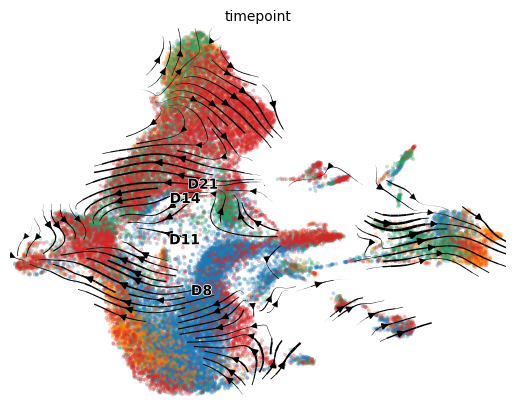

In [22]:
scv.pl.velocity_embedding_stream(
    adata_final,
    basis="umap",
    color="timepoint",
)


In [23]:
del adata_final.uns['neighbors']

In [24]:
sc.pp.neighbors(adata_final)

In [25]:
sc.tl.paga(adata_final,groups="leiden_raw")

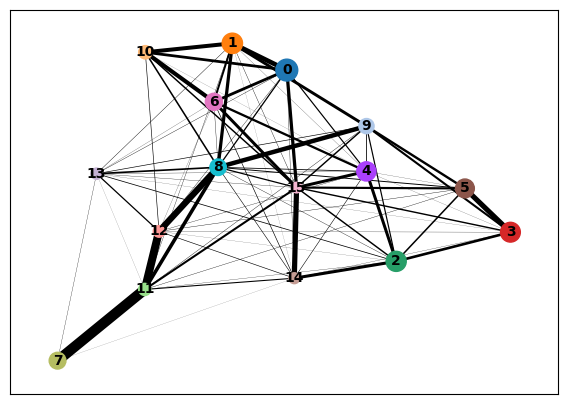

In [26]:
sc.pl.paga(adata_final)

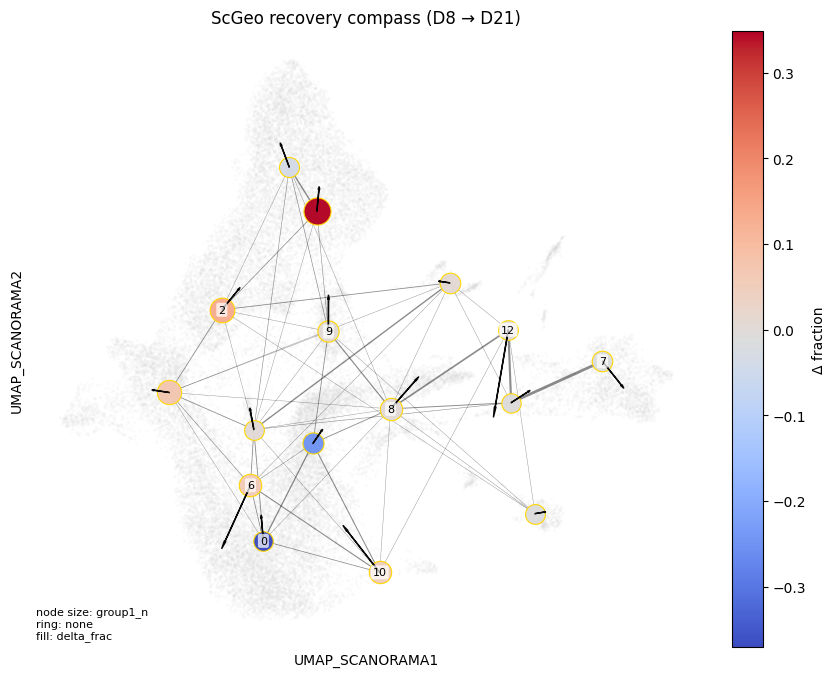

(<Figure size 950x800 with 2 Axes>,
 <Axes: title={'center': 'ScGeo recovery compass (D8 → D21)'}, xlabel='UMAP_SCANORAMA1', ylabel='UMAP_SCANORAMA2'>)

In [27]:
sg.pl.recovery_compass(
    adata_final,
    node_key="leiden_raw",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap_scanorama",
    paga_key="paga",
    min_cells=20,
    label_top_n=8,
    ring_mode="none",
    fill_color_mode="delta_frac",
    arrow_color_mode="constant"
)

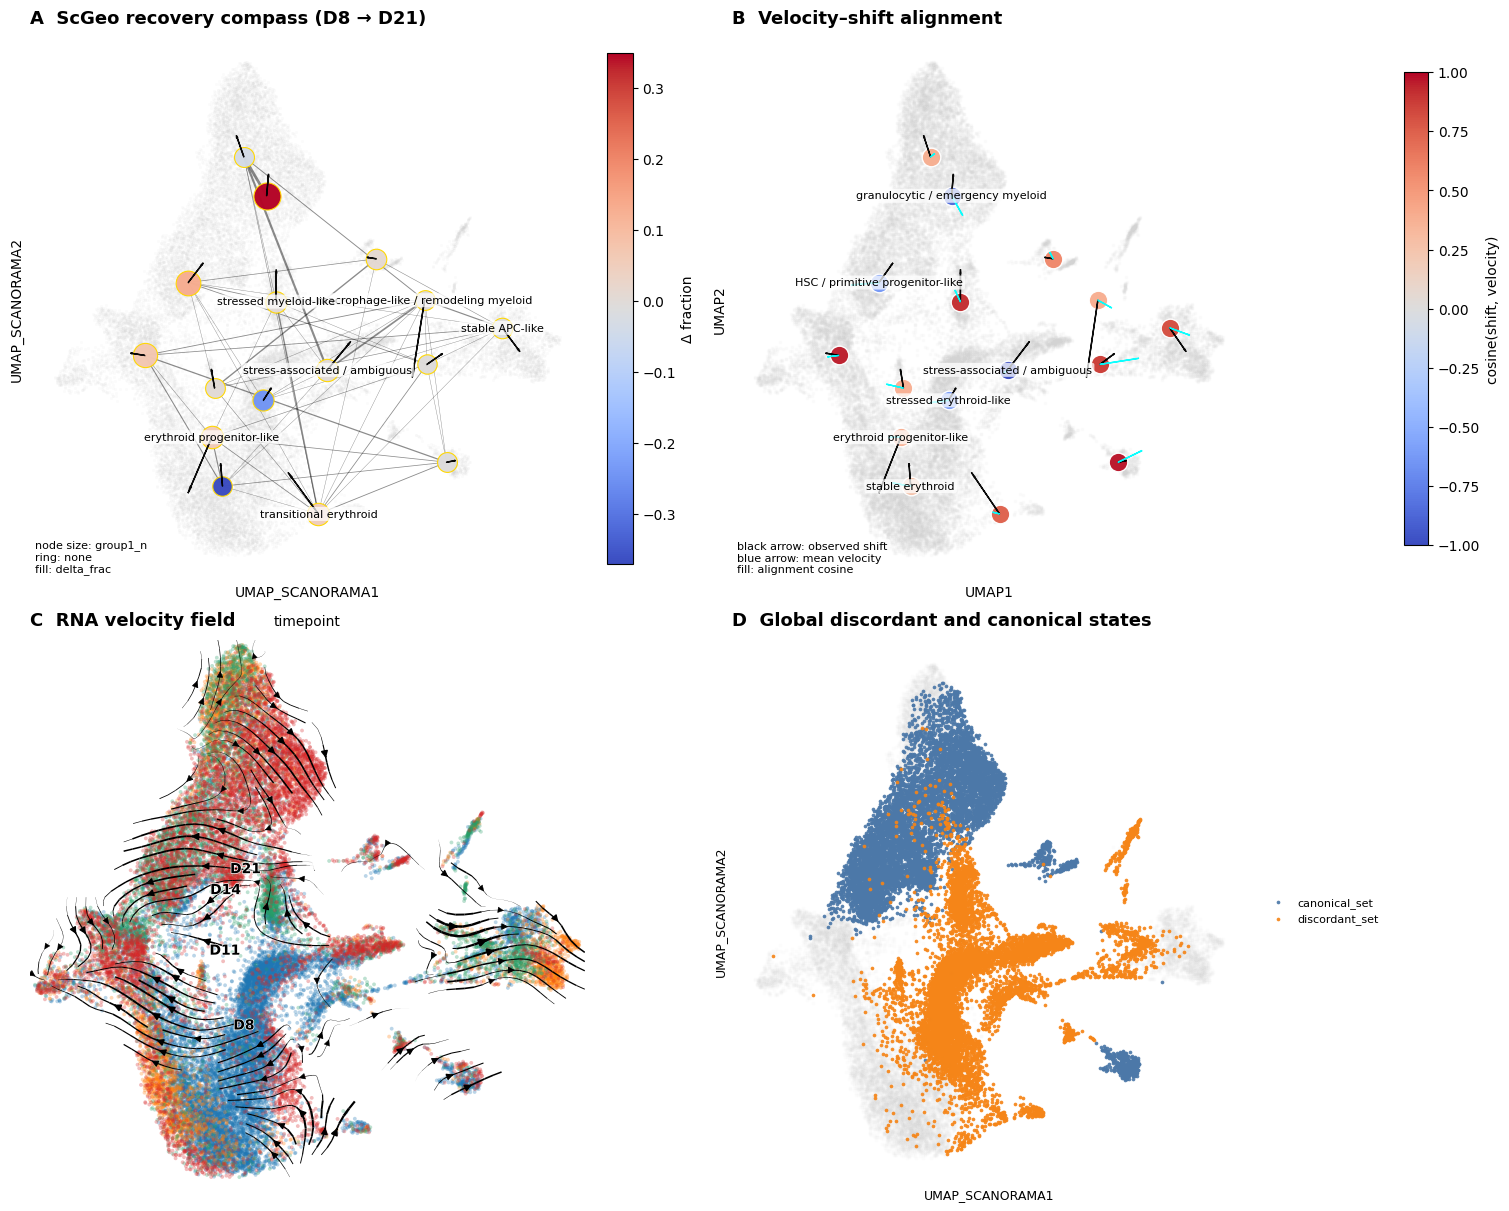

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import scgeo as sg
from matplotlib.gridspec import GridSpec

# =========================================================
# Figure 2 — geometry / dynamics / recovery
# Option 1:
#   A = recovery compass
#   B = velocity–shift alignment
#   C = velocity stream
#   D = global discordant vs canonical UMAP
# =========================================================

# -----------------------------
# expected inputs
# -----------------------------
# adata_final
# obs key:
#   state_set  with:
#       canonical_set
#       discordant_set
#       other
# embeddings:
#   X_umap_scanorama
#   X_umap
# velocity basis:
#   velocity_umap
# -----------------------------

# -----------------------------
# palette
# -----------------------------
palette_global = {
    "canonical_set": "#4C78A8",
    "discordant_set": "#F58518",
    "other": "#D9D9D9",
}


def plot_set_umap_manual(
    adata,
    key,
    ax,
    colors,
    basis="umap_scanorama",
    title=None,
    other_label="other",
    size=7,
    alpha_other=0.08,
    alpha_main=0.90,
):
    key_basis = basis if basis.startswith("X_") else f"X_{basis}"
    xy = adata.obsm[key_basis]
    s = adata.obs[key].astype(str)

    if other_label in set(s):
        mask_other = (s == other_label).to_numpy()
        ax.scatter(
            xy[mask_other, 0],
            xy[mask_other, 1],
            s=size,
            c=colors.get(other_label, "#D9D9D9"),
            alpha=alpha_other,
            linewidths=0,
            rasterized=True,
        )

    for cat, col in colors.items():
        if cat == other_label:
            continue
        mask = (s == cat).to_numpy()
        if mask.sum() == 0:
            continue
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=size,
            c=col,
            alpha=alpha_main,
            linewidths=0,
            rasterized=True,
            label=cat,
        )

    ax.set_title(title, fontsize=12, loc="left", pad=4)
    ax.set_xlabel("UMAP_SCANORAMA1", fontsize=9)
    ax.set_ylabel("UMAP_SCANORAMA2", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))


# =========================================================
# Build figure
# =========================================================

fig = plt.figure(figsize=(15, 12), constrained_layout=True)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    height_ratios=[1.0, 1.0],
    width_ratios=[1.08, 1.0],
)

# ---------------------------------------------------------
# A. Recovery compass
# ---------------------------------------------------------
axA = fig.add_subplot(gs[0, 0])
sg.pl.recovery_compass(
    adata_final,
    node_key="cluster_label_manual",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap_scanorama",
    paga_key="paga",
    min_cells=20,
    label_top_n=6,
    ring_mode="none",
    fill_color_mode="delta_frac",
    arrow_color_mode="constant",
    ax=axA,
    title="",  
    show=False,
)
axA.set_title(
    "A  ScGeo recovery compass (D8 → D21)",
    loc="left", fontsize=13, fontweight="bold", pad=10
)

# ---------------------------------------------------------
# B. Velocity–shift alignment
# ---------------------------------------------------------
axB = fig.add_subplot(gs[0, 1])
sg.pl.velocity_shift_alignment(
    adata_final,
    node_key="cluster_label_manual",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap",
    velocity_basis="umap",
    min_cells=20,
    label_top_n=6,
    label_mode="discordant",
    ax=axB,
    title="",
    show=False,
)

axB.set_title(
    "B  Velocity–shift alignment",
    loc="left", fontsize=13, fontweight="bold", pad=10
)


# ---------------------------------------------------------
# C. Velocity stream
# ---------------------------------------------------------
axC = fig.add_subplot(gs[1, 0])
scv.pl.velocity_embedding_stream(
    adata_final,
    basis="umap",
    color="timepoint",
    ax=axC,
    show=False,
)
axC.set_title(
    "C  RNA velocity field",
    loc="left", fontsize=13, fontweight="bold", pad=10
)


# ---------------------------------------------------------
# D. Global discordant vs canonical UMAP
# ---------------------------------------------------------
axD = fig.add_subplot(gs[1, 1])
plot_set_umap_manual(
    adata_final,
    key="state_set",
    ax=axD,
    colors=palette_global,
    basis="umap_scanorama",
    title="D  Global discordant vs canonical sets",
    other_label="other",
    size=7,
    alpha_other=0.08,
    alpha_main=0.92,
)
axD.set_title(
    "D  Global discordant and canonical states",
    loc="left", fontsize=13, fontweight="bold", pad=10
)
plt.savefig("Figure3.tiff", dpi=600, format="tiff", bbox_inches="tight")
plt.show()


Global: ['Car1', 'Slc25a21', 'Ermap', 'Ank1', 'Abcb4', 'Aqp1', 'Nfia', 'Myo1d', 'Klf1', 'Gm15915']
Ery: ['Adgrl4', 'Serpinb1a', 'Irf8', 'Fcer1g', 'Cd52', 'Cers6', 'Ly6c2', 'Sox6', 'Ms4a3', 'Hba-a2']
My: ['Gm26917', 'Fabp4', 'Tgfbr3', 'Gimap6', 'Sparc', 'Stab2', 'Esam', 'Magi1', 'Galnt18', 'Abcc9']


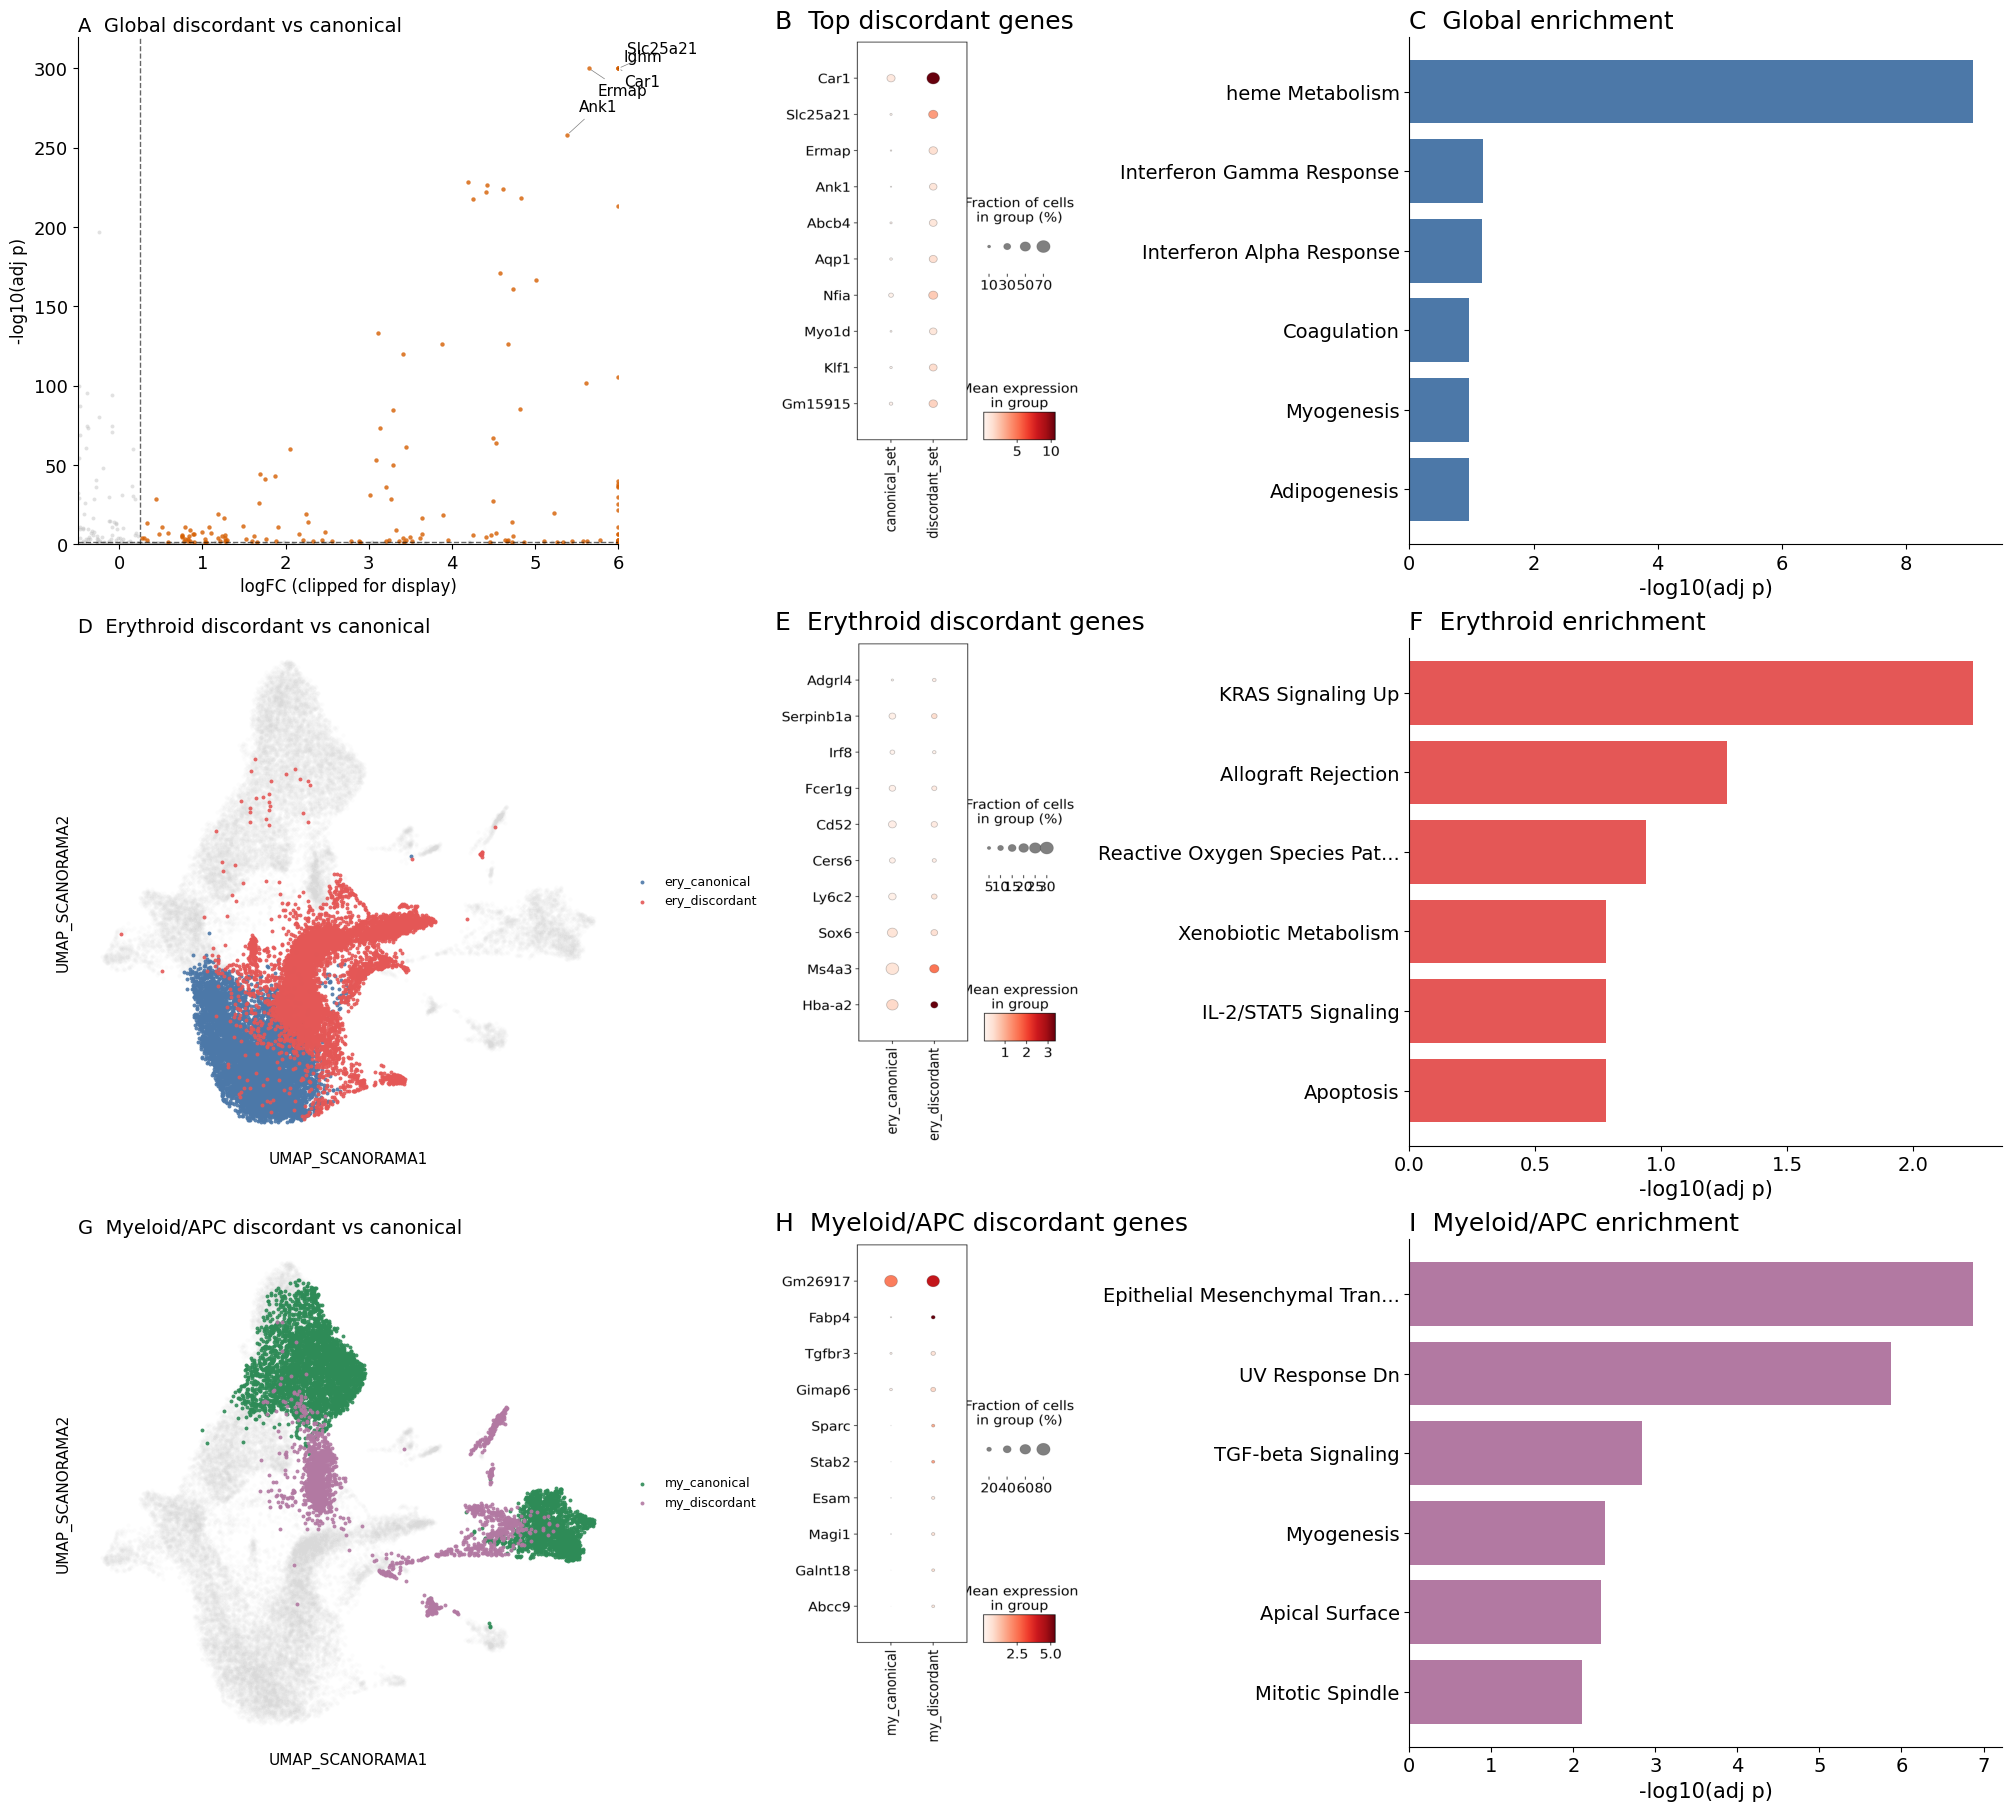

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.gridspec import GridSpec
import tempfile
import matplotlib.image as mpimg
# =========================================================
# Helpers
# =========================================================
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})
def filter_deg(df, lfc=0.25, padj=0.05):
    return df.query("pvals_adj < @padj and logfoldchanges > @lfc").copy()

def top_genes(df, n=10):
    return df["names"].dropna().head(n).tolist()

def shorten_term(term, max_len=24):
    term = str(term)
    return term if len(term) <= max_len else term[: max_len - 3] + "..."

def plot_set_umap_manual(
    adata,
    key,
    ax,
    colors,
    basis="umap_scanorama",
    title=None,
    other_label="other",
    size=8,
    alpha_other=0.08,
    alpha_main=0.90,
):
    key_basis = basis if basis.startswith("X_") else f"X_{basis}"
    xy = adata.obsm[key_basis]
    s = adata.obs[key].astype(str)

    if other_label in set(s):
        mask_other = (s == other_label).to_numpy()
        ax.scatter(
            xy[mask_other, 0],
            xy[mask_other, 1],
            s=size,
            c=colors.get(other_label, "#D9D9D9"),
            alpha=alpha_other,
            linewidths=0,
            rasterized=True,
        )

    for cat, col in colors.items():
        if cat == other_label:
            continue
        mask = (s == cat).to_numpy()
        if mask.sum() == 0:
            continue
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=size,
            c=col,
            alpha=alpha_main,
            linewidths=0,
            rasterized=True,
            label=cat,
        )

    ax.set_title(title, fontsize=14, loc="left", pad=4)
    ax.set_xlabel("UMAP_SCANORAMA1", fontsize=11)
    ax.set_ylabel("UMAP_SCANORAMA2", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc="center left", bbox_to_anchor=(1.00, 0.5))

def plot_enrichment_bar(
    enr_df,
    ax,
    title,
    color="#4C78A8",
    top_n=5,
    term_max_len=30,
):
    df = enr_df.sort_values("Adjusted P-value").head(top_n).copy()
    df = df[df["Adjusted P-value"] > 0].copy()
    df["score"] = -np.log10(df["Adjusted P-value"])
    df["Term_short"] = df["Term"].map(lambda x: shorten_term(x, max_len=term_max_len))
    df = df.sort_values("score", ascending=True)

    ax.barh(df["Term_short"], df["score"], color=color)

    # 🔥 BIGGER TEXT
    ax.set_xlabel("-log10(adj p)", fontsize=15)
    ax.set_title(title, fontsize=18, loc="left", pad=6)

    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
def plot_deg_volcano(
    df,
    ax,
    title,
    gene_col="names",
    lfc_col="logfoldchanges",
    p_col="pvals_adj",
    top_n=5,
    lfc_thr=0.25,
    p_thr=0.05,
    up_color="#D55E00",
    ns_color="#BDBDBD",
    x_clip=(-0.5, 6),
    ylim=(0, 320),
):
    d = df.copy()
    d[lfc_col] = pd.to_numeric(d[lfc_col], errors="coerce")
    d[p_col] = pd.to_numeric(d[p_col], errors="coerce")
    d["neglog10p"] = -np.log10(np.clip(d[p_col], 1e-300, 1.0))

    # keep display focused on relevant region
    d = d[d[lfc_col] > x_clip[0]].copy()
    d["lfc_plot"] = d[lfc_col].clip(lower=x_clip[0], upper=x_clip[1])

    sig = (d[p_col] < p_thr) & (d[lfc_col] > lfc_thr)

    ax.scatter(
        d.loc[~sig, "lfc_plot"],
        d.loc[~sig, "neglog10p"],
        s=8,
        c=ns_color,
        alpha=0.45,
        linewidths=0,
        rasterized=True,
    )
    ax.scatter(
        d.loc[sig, "lfc_plot"],
        d.loc[sig, "neglog10p"],
        s=10,
        c=up_color,
        alpha=0.80,
        linewidths=0,
        rasterized=True,
    )

    ax.axvline(lfc_thr, linestyle="--", linewidth=1, color="black", alpha=0.6)
    ax.axhline(-np.log10(p_thr), linestyle="--", linewidth=1, color="black", alpha=0.6)

    # label only a few strongest hits and offset labels
    top = d.loc[sig].sort_values([p_col, lfc_col], ascending=[True, False]).head(top_n)
    offsets = [(4, 8), (4, -10), (6, 14), (6, -16), (8, 20), (8, -22)]

    for i, (_, row) in enumerate(top.iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            str(row[gene_col]),
            xy=(row["lfc_plot"], row["neglog10p"]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=11,
            ha="left",
            va="center",
            arrowprops=dict(arrowstyle="-", lw=0.5, color="black", alpha=0.5),
        )

    ax.set_xlabel("logFC (clipped for display)", fontsize=12)
    ax.set_ylabel("-log10(adj p)", fontsize=12)
    ax.set_title(title, fontsize=14, loc="left", pad=4)
    ax.set_xlim(*x_clip)
    if ylim is not None:
        ax.set_ylim(*ylim)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

def crop_white_rgba(
    img,
    white_thresh=250,
    pad_left=45,
    pad_right=8,
    pad_top=8,
    pad_bottom=18,
):
    """
    Crop white margins from an RGBA image array, keeping extra space on the
    left/bottom so gene labels and x labels are not cut off.
    """
    rgb = img[..., :3]
    mask = np.any(rgb < white_thresh, axis=2)

    if not mask.any():
        return img

    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]

    r0 = max(rows[0] - pad_top, 0)
    r1 = min(rows[-1] + pad_bottom + 1, img.shape[0])
    c0 = max(cols[0] - pad_left, 0)
    c1 = min(cols[-1] + pad_right + 1, img.shape[1])

    return img[r0:r1, c0:c1, :]


def draw_scanpy_dotplot_on_ax(
    adata,
    mask,
    var_names,
    groupby,
    ax,
    layer="matrix",
    title=None,
    figsize=(3.8, 8.5),   # narrower, taller -> closer to default scanpy look
):
    dp = sc.pl.dotplot(
        adata[mask],
        var_names=var_names,
        groupby=groupby,
        layer=layer,
        swap_axes=True,
        show=False,
        return_fig=True,
        figsize=figsize,
    )
    dp.make_figure()

    # enlarge all text inside the scanpy-generated figure
    for txt in dp.fig.findobj(match=plt.Text):
        txt.set_fontsize(15)

    # save to temporary image
    with tempfile.NamedTemporaryFile(suffix=".png", delete=False) as tmp:
        tmp_path = tmp.name

    dp.fig.savefig(
        tmp_path,
        dpi=320,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(dp.fig)

    img = mpimg.imread(tmp_path)

    # tighter crop: much less side whitespace, keep room for gene labels + legends
    img = crop_white_rgba(
        img,
        white_thresh=250,
        pad_left=6,
        pad_right=4,
        pad_top=8,
        pad_bottom=12,
    )

    ax.imshow(img, aspect="auto")
    ax.axis("off")
    ax.set_title(title, fontsize=18, loc="left", pad=6)
# =========================================================
# Prepare inputs
# =========================================================

deg_global_sig = filter_deg(deg_global_sets)
deg_ery_sig = filter_deg(deg_ery_sets)
deg_my_sig = filter_deg(deg_my_sets)

top_global = top_genes(deg_global_sig, n=10)
top_ery = top_genes(deg_ery_sig, n=10)
top_my = top_genes(deg_my_sig, n=10)

print("Global:", top_global)
print("Ery:", top_ery)
print("My:", top_my)

palette_global = {
    "canonical_set": "#4C78A8",
    "discordant_set": "#F58518",
    "other": "#D9D9D9",
}
palette_ery = {
    "ery_canonical": "#4C78A8",
    "ery_discordant": "#E45756",
    "other": "#D9D9D9",
}
palette_my = {
    "my_canonical": "#2E8B57",
    "my_discordant": "#B279A2",
    "other": "#D9D9D9",
}

# =========================================================
# Build Figure 3
fig = plt.figure(figsize=(20, 18), constrained_layout=True)

gs = GridSpec(
    nrows=3,
    ncols=3,
    figure=fig,
    height_ratios=[1.0, 1.0, 1.0],
    width_ratios=[1.05, 0.60, 1.15],
)
# -------------------------
# Row 1: Global
# -------------------------
axA = fig.add_subplot(gs[0, 0])
plot_deg_volcano(
    deg_global_sets,
    ax=axA,
    title="A  Global discordant vs canonical",
    top_n=5,
    x_clip=(-0.5, 6),
    ylim=(0, 320),
)

axB = fig.add_subplot(gs[0, 1])
mask_global = adata_final.obs["state_set"].isin(["canonical_set", "discordant_set"]).to_numpy()
draw_scanpy_dotplot_on_ax(
    adata_final,
    mask=mask_global,
    var_names=top_global,
    groupby="state_set",
    ax=axB,
    layer="matrix",
    title="B  Top discordant genes",
)

axC = fig.add_subplot(gs[0, 2])
plot_enrichment_bar(
    enr_global,
    ax=axC,
    title="C  Global enrichment",
    color="#4C78A8",
    top_n=6,
)

# -------------------------
# Row 2: Erythroid
# -------------------------
axD = fig.add_subplot(gs[1, 0])
plot_set_umap_manual(
    adata_final,
    key="ery_state_set",
    ax=axD,
    colors=palette_ery,
    basis="umap_scanorama",
    title="D  Erythroid discordant vs canonical",
)

axE = fig.add_subplot(gs[1, 1])
mask_ery = adata_final.obs["ery_state_set"].isin(["ery_canonical", "ery_discordant"]).to_numpy()
draw_scanpy_dotplot_on_ax(
    adata_final,
    mask=mask_ery,
    var_names=top_ery,
    groupby="ery_state_set",
    ax=axE,
    layer="matrix",
    title="E  Erythroid discordant genes",
)

axF = fig.add_subplot(gs[1, 2])
plot_enrichment_bar(
    enr_ery,
    ax=axF,
    title="F  Erythroid enrichment",
    color="#E45756",
    top_n=6,
)

# -------------------------
# Row 3: Myeloid/APC
# -------------------------
axG = fig.add_subplot(gs[2, 0])
plot_set_umap_manual(
    adata_final,
    key="my_state_set",
    ax=axG,
    colors=palette_my,
    basis="umap_scanorama",
    title="G  Myeloid/APC discordant vs canonical",
)

axH = fig.add_subplot(gs[2, 1])
mask_my = adata_final.obs["my_state_set"].isin(["my_canonical", "my_discordant"]).to_numpy()
draw_scanpy_dotplot_on_ax(
    adata_final,
    mask=mask_my,
    var_names=top_my,
    groupby="my_state_set",
    ax=axH,
    layer="matrix",
    title="H  Myeloid/APC discordant genes",
)

axI = fig.add_subplot(gs[2, 2])
plot_enrichment_bar(
    enr_my,
    ax=axI,
    title="I  Myeloid/APC enrichment",
    color="#B279A2",
    top_n=6,
)
plt.savefig("Figure4.tiff", dpi=600, format="tiff", bbox_inches="tight")
plt.show()

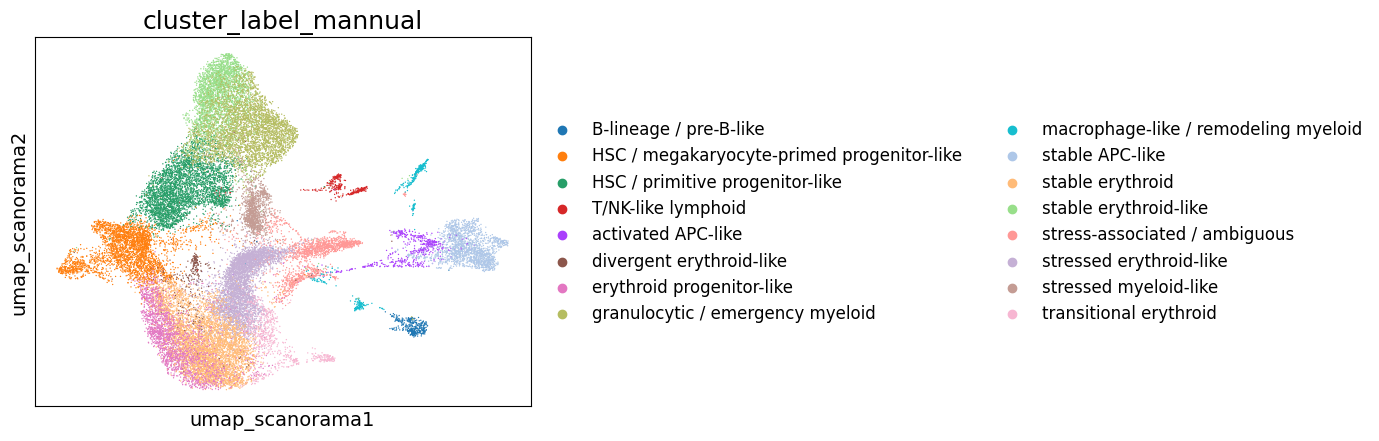

In [30]:
sc.pl.embedding(
    adata_final,
    basis="umap_scanorama",
    color="cluster_label_mannual")

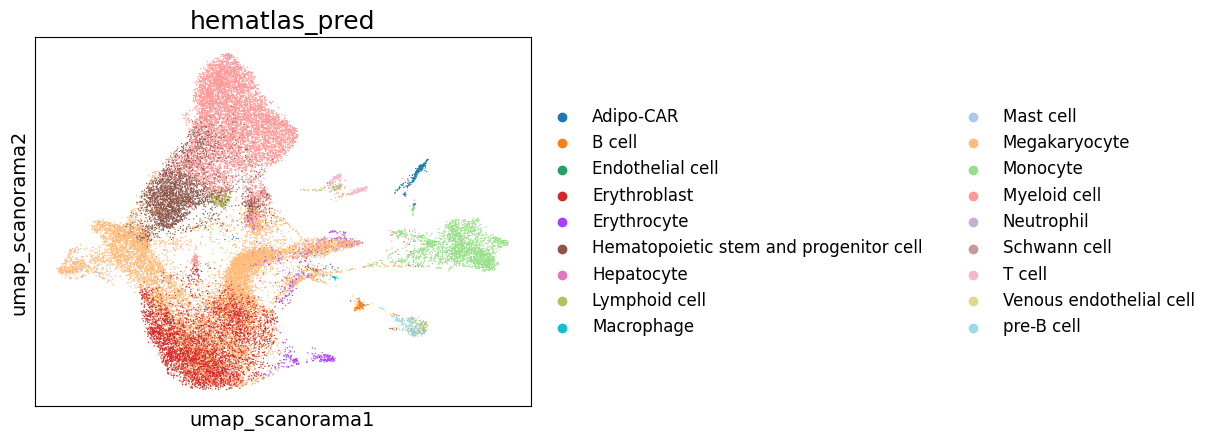

In [31]:
 sc.pl.embedding(
    adata_final,
    basis="umap_scanorama",
    color= "hematlas_pred"
 )

In [32]:
def plot_annotation_table_colored(
    adata,
    cluster_key="cluster_label_manual",
    leiden_key="leiden_raw",
    ax=None,
):
    import pandas as pd
    import matplotlib.pyplot as plt

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))

    # ---- Build mapping ----
    df = (
        adata.obs[[cluster_key, leiden_key]]
        .drop_duplicates()
        .sort_values(leiden_key)
    )

    df.columns = ["Annotation", "Cluster"]
    df = df[["Cluster", "Annotation"]]

    # ---- Get colors from Scanpy ----
    if f"{leiden_key}_colors" in adata.uns:
        palette = adata.uns[f"{leiden_key}_colors"]
    else:
        import seaborn as sns
        palette = sns.color_palette("tab20", n_colors=df.shape[0])

    cluster_to_color = {
        int(k): palette[int(k) % len(palette)]
        for k in df["Cluster"]
    }

    ax.axis("off")

    # ---- Create table ----
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="left",
        colWidths=[0.18, 0.82],  # <-- KEY FIX
    )

    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.5)

    # ---- Style cells ----
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
        else:
            if col == 0:  # Cluster column
                cluster_id = int(df.iloc[row - 1, 0])
                cell.set_facecolor(cluster_to_color[cluster_id])
                cell.set_text_props(color="black", weight="bold")

   # ax.set_title("E  Cluster annotation", fontsize=12, fontweight="bold")

    return ax

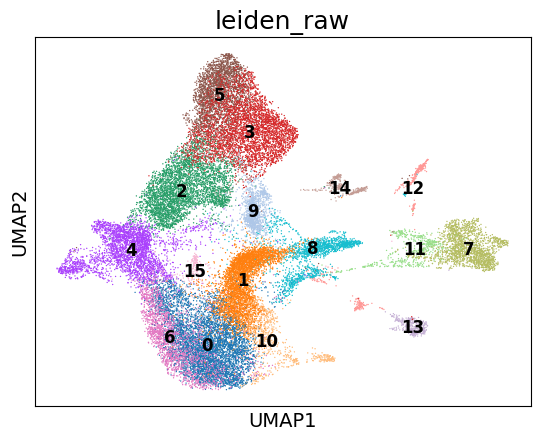

In [33]:
sc.pl.umap(
    adata_final,
    color="leiden_raw",legend_loc='on data')

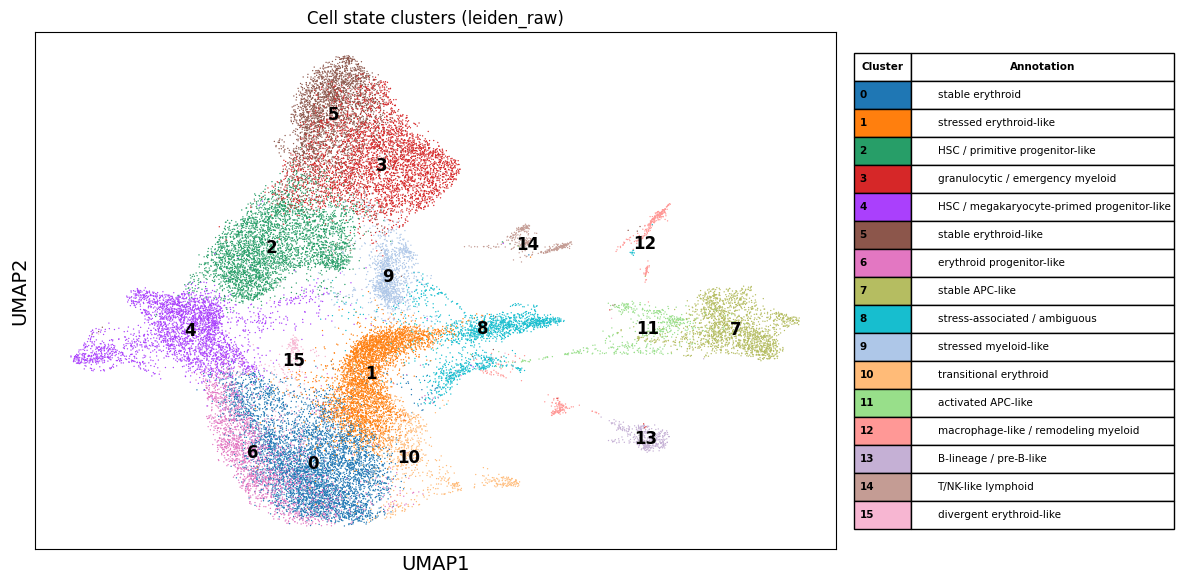

In [34]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1.2])

# ---- UMAP ----
ax1 = fig.add_subplot(gs[0, 0])
sc.pl.umap(
    adata_final,
    color="leiden_raw",
    legend_loc="on data",
    ax=ax1,
    show=False,
)
ax1.set_title("Cell state clusters (leiden_raw)", fontsize=12)

# ---- TABLE ----
ax2 = fig.add_subplot(gs[0, 1])
plot_annotation_table_colored(
    adata_final,
    cluster_key="cluster_label_manual",
    ax=ax2,
)

plt.tight_layout()
plt.show()

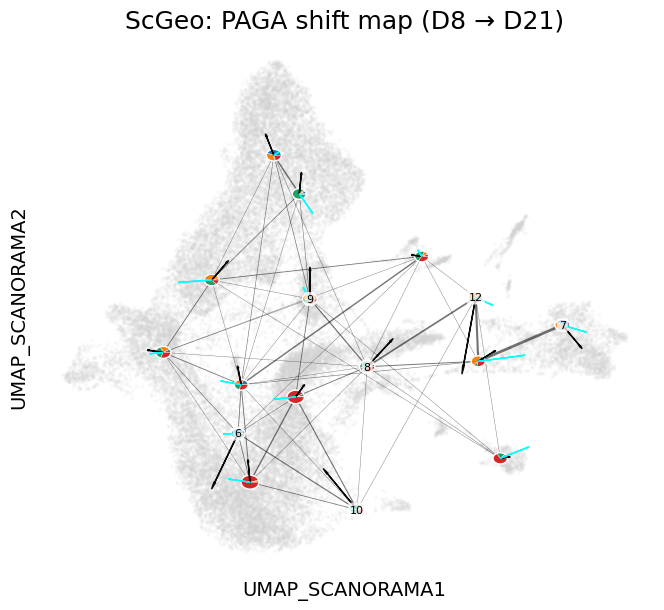

In [35]:
fig, ax, out = sg.pl.paga_scgeo(
    adata_final,
    node_key="leiden_raw",
    condition_key="timepoint",
    group0="D8",
    group1="D21",
    basis="umap_scanorama",
    paga_key="paga",
    pie_key="timepoint",
    velocity_basis="umap",
    show_velocity=True,
    node_color_mode="delta",
    label_top_n=6,
    min_cells=20,
    connectivity_threshold=0.05,
    show=False,
    return_data=True,
)

In [36]:
from PIL import Image

img = Image.open("Figure1.png")
img.save("Figure1.tiff", dpi=(600,600))

In [37]:
img = Image.open("Figure2.png")
img.save("Figure2.tiff", dpi=(600,600))